In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import time
import io
import logging
import re
import gget
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from scipy.stats import ttest_ind
from tqdm import tqdm
import os
from itertools import combinations
import pickle
import shutil
from scipy.sparse import csr_matrix

import textwrap
from sklearn.metrics import mean_squared_error
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

from scvi.external import CellAssign

import cupy as cp
import cuml

from gears import PertData, GEARS

sc.settings.verbosity = 3

/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
print(f"{np.__version__=}")

np.__version__='1.26.4'


In [3]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/pseudotime.h5ad"
adata = sc.read_h5ad(fpath)
adata.X = adata.layers['raw_counts'].copy()

sc.pp.filter_genes(adata, min_counts=30)

# preprocessing
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, subset=True, n_top_genes=10000, batch_key='batch')

adata

filtered out 1493 genes that are detected in less than 30 counts
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:03)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
CPU times: user 4.68 s, sys: 8.45 s, total: 13.1 s
Wall time: 15.1 s


AnnData object with n_obs × n_vars = 15867 × 10000
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str', 'barcoded_phase', 'S_score', 'G2M_score', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'G1_pseudotime', 'G1_order', 'G2M_pseudotime', 'G2M_order', 'mean_pseudotime', 'mean_order', 'nnz'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersio

In [4]:
# structure metadata

# simple features
adata.obs['cell_type'] = 'bj_fib'
adata.var['gene_name'] = adata.var.index.copy()

# pseudo perturb-seq
condition_map = { 
    'C1' : "exp",
    'C2' : "exp",
    'C3' : "exp",
    'C4' : "ctrl", 
    'C5' : "ctrl",
}

adata.obs['condition'] = adata.obs['cluster_str'].map(condition_map)
adata.obs['condition'] = np.where(adata.obs['batch'] == 'fib', "ctrl", adata.obs['condition']) # only actually reprogrammed cells
print(adata.obs['condition'].value_counts().to_string())

# Your category names
tf_recipe = [
    'GATA2',
    'FOS',
    'STAT5A',
    'GFI1B',
    'REL',
]

# Filter to only 'exp' cells
exp_cells = adata[adata.obs['condition'] == 'exp'].to_df()
exist = [x for x in exp_cells.columns if x in tf_recipe]
exp_cells = exp_cells[exist].astype(bool)

import pandas as pd
import numpy as np

# TFs that exist in the dataset
exist = [x for x in tf_recipe if x in exp_cells.columns]
n = len(tf_recipe)
cell_assignments = pd.Series(index=exp_cells.index, dtype=object)

# Track unassigned cells
unassigned = exp_cells.copy()

# First pass: assign cells that express a given TF
for tf in exist:
    mask = (unassigned[tf] == True) & (cell_assignments.isna())
    n_target = len(exp_cells) // n
    selected = mask[mask].sample(min(n_target, mask.sum()), random_state=0).index
    cell_assignments.loc[selected] = tf
    unassigned = unassigned.drop(index=selected)

# Second pass: assign remaining cells to balance category sizes
remaining = cell_assignments.isna()
needed = (len(exp_cells) // n) - cell_assignments.value_counts().fillna(0).astype(int)
needed = needed.reindex(tf_recipe, fill_value=0)

for tf in tf_recipe:
    n_to_fill = needed[tf]
    if n_to_fill > 0:
        fill_cells = cell_assignments[remaining].sample(n=n_to_fill, random_state=0).index
        cell_assignments.loc[fill_cells] = tf
        remaining = cell_assignments.isna()

# If any still remain unassigned (due to rounding), assign arbitrarily
if cell_assignments.isna().sum() > 0:
    final_fill = cell_assignments[cell_assignments.isna()].index
    random_fill = np.random.choice(tf_recipe, size=len(final_fill), replace=True)
    cell_assignments.loc[final_fill] = random_fill

# Final result
exp_cells['assigned_tf'] = cell_assignments
exp_cells['assigned_tf'] = exp_cells['assigned_tf'].apply(lambda x : x + "+ctrl")
exp_cells['assigned_tf'].value_counts()

condition_map = dict(zip(exp_cells.index, exp_cells['assigned_tf'].values))
adata.obs['condition'] = adata.obs['condition'].where(
    ~adata.obs.index.isin(condition_map),
    adata.obs.index.map(condition_map)
)

print()

print(adata.obs['condition'].value_counts().to_string())

condition
ctrl    9473
exp     6394

condition
ctrl           9473
GATA2+ctrl     1783
FOS+ctrl       1775
REL+ctrl       1772
STAT5A+ctrl     535
GFI1B+ctrl      529


# Create Dataset Object

In [5]:
%%time
outpath = "./data"
dataset_name = "pseudotime"
clear = True

if clear and os.path.exists(outpath):
    print(f"Clearing: {outpath}")
    for f in os.listdir(outpath):
        p = os.path.join(outpath, f)
        if os.path.isdir(p):
            shutil.rmtree(p)
        else:
            os.remove(p)
    print("Done.\n")

print(f"Loading PertData at {outpath}")
pert_data = PertData(outpath)

print(f"Processing: {dataset_name}")
pert_data.new_data_process(
    dataset_name=dataset_name, 
    adata=adata.copy(),
)

Clearing: ./data


Downloading...


Done.

Loading PertData at ./data


100%|██████████| 9.46M/9.46M [00:00<00:00, 40.3MiB/s]


Processing: pseudotime
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:01)


Downloading...
100%|██████████| 559k/559k [00:00<00:00, 6.17MiB/s]
Creating pyg object for each cell in the data...
Creating dataset file...
100%|██████████| 6/6 [00:58<00:00,  9.78s/it]
Done!
Saving new dataset pyg object at ./data/pseudotime/data_pyg/cell_graphs.pkl
Done!


CPU times: user 1min 2s, sys: 6.45 s, total: 1min 9s
Wall time: 1min 17s


# Load Data 

In [6]:
%%time
pert_data = PertData(
    outpath,
)

pert_data.load(data_path = f"{outpath}/{dataset_name}") 

pert_data.prepare_split(
    split='simulation', 
    seed=1,
) 

print(pert_data.set2conditions)
pert_data.get_dataloader(batch_size = 256, test_batch_size = 256) # prepare data loader

Found local copy...
Found local copy...
These perturbations are not in the GO graph and their perturbation can thus not be predicted
[]
Local copy of pyg dataset is detected. Loading...
Done!
Creating new splits....
Saving new splits at ./data/pseudotime/splits/pseudotime_simulation_1_0.75.pkl
Simulation split test composition:
combo_seen0:0
combo_seen1:0
combo_seen2:0
unseen_single:2
Done!
Creating dataloaders....
Done!


{'test': ['REL+ctrl', 'FOS+ctrl'], 'train': ['STAT5A+ctrl', 'GATA2+ctrl', 'ctrl'], 'val': ['GFI1B+ctrl']}
CPU times: user 4.13 s, sys: 3.52 s, total: 7.65 s
Wall time: 10.6 s


# Model Config

In [7]:
def densify_adata(adata):
    if isinstance(adata.X, csr_matrix):
        adata.X = adata.X.toarray().copy()
    return adata

# force dense for this part
pert_data.adata = densify_adata(pert_data.adata).copy()
print(f"{type(pert_data.adata.X)=}")

gears_model = GEARS(
    pert_data,
    device='cuda',
    weight_bias_track = False, 
    proj_name = 'test1', 
    exp_name = 'test2',  
) 

# force sparse for graph construction
gears_model.adata.X = csr_matrix(gears_model.adata.X)
print(f"{type(gears_model.adata.X)=}")

print()   

print(f"Data path: {gears_model.data_path}")
print(f"Data name: {gears_model.dataset_name}")

type(pert_data.adata.X)=<class 'numpy.ndarray'>
type(gears_model.adata.X)=<class 'scipy.sparse._csr.csr_matrix'>

Data path: ./data
Data name: pseudotime


# Init and Train

In [8]:
%%time
gears_model.model_initialize(
    # num_similar_genes_go_graph=50,
    # num_similar_genes_co_express_graph=50,
    # coexpress_threshold=0.5,
)

# Capture stderr
stderr_buffer = io.StringIO()
old_stderr = sys.stderr
sys.stderr = stderr_buffer

# Run the function that prints to stderr
gears_model.train(
    epochs=10, 
    lr=1e-3, 
)

# Restore stderr
sys.stderr = old_stderr

# Get the captured output
captured_output = stderr_buffer.getvalue()
stderr_buffer.close()

Downloading...
100%|██████████| 60.7M/60.7M [00:02<00:00, 21.4MiB/s]
Extracting tar file...
Done!


CPU times: user 6min 43s, sys: 41.3 s, total: 7min 24s
Wall time: 6min 59s


   epoch  train_mse  val_mse  train_de_mse  val_de_mse
0      1     0.0082   0.0106        0.3415      0.2366
1      2     0.0066   0.0220        0.2321      1.0902
2      3     0.0052   0.0096        0.2250      0.4300
3      4     0.0053   0.0162        0.1815      0.8070
4      5     0.0050   0.0151        0.1862      0.7444
5      6     0.0052   0.0138        0.2182      0.6573
6      7     0.0053   0.0138        0.1714      0.6589
7      8     0.0054   0.0131        0.1127      0.6202
8      9     0.0055   0.0126        0.0960      0.5883
9     10     0.0053   0.0136        0.1440      0.6477


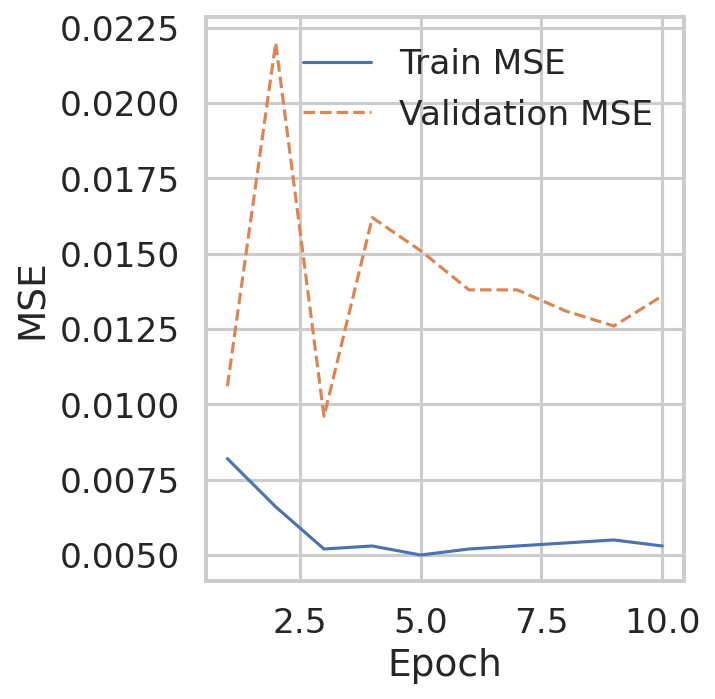

In [9]:
pattern = re.compile(
    r"Epoch (\d+): Train Overall MSE: ([\d.]+) Validation Overall MSE: ([\d.]+).*?"
    r"Train Top 20 DE MSE: ([\d.]+) Validation Top 20 DE MSE: ([\d.]+)",
    re.DOTALL
)

records = []
for match in pattern.finditer(captured_output):
    epoch, train_mse, val_mse, train_de, val_de = match.groups()
    records.append({
        "epoch": int(epoch),
        "train_mse": float(train_mse.rstrip('.')),
        "val_mse": float(val_mse.rstrip('.')),
        "train_de_mse": float(train_de.rstrip('.')),
        "val_de_mse": float(val_de.rstrip('.')),
    })


df_metrics = pd.DataFrame(records)
print(df_metrics)

# Plot style
sns.set(style="whitegrid", context="talk")
plt.figure(figsize=(5, 5), dpi=150)

# Plot both curves with clear labels
sns.lineplot(data=df_metrics, x='epoch', y='train_mse', label='Train MSE', linewidth=1.5)
sns.lineplot(data=df_metrics, x='epoch', y='val_mse', label='Validation MSE', linewidth=1.5, linestyle='--')

# Axis labels and title
plt.xlabel("Epoch")
plt.ylabel("MSE")

# Legend and layout
plt.legend(frameon=False)
plt.tight_layout()

plt.show()

# Prediction Error (Individual)

In [10]:
# get the single tf perturbations
tf_recipe = ['GATA2', 'GFI1B', 'FOS', 'STAT5A', 'REL']
query = [[x] for x in tf_recipe]
res = pd.DataFrame(gears_model.predict(query))

res.shape=(10000, 5)
           GATA2     GFI1B       FOS    STAT5A       REL
A2M    -0.316580 -0.246242 -0.254253 -0.184110 -0.248837
A4GALT  0.303098  0.261093  0.286376  0.228391  0.272302
A4GNT  -0.012952 -0.002812 -0.007885 -0.010813 -0.013650
AAK1    0.662291  0.603768  0.619202  0.680336  0.658331
AARD   -0.301117 -0.207884 -0.245168 -0.166930 -0.197563



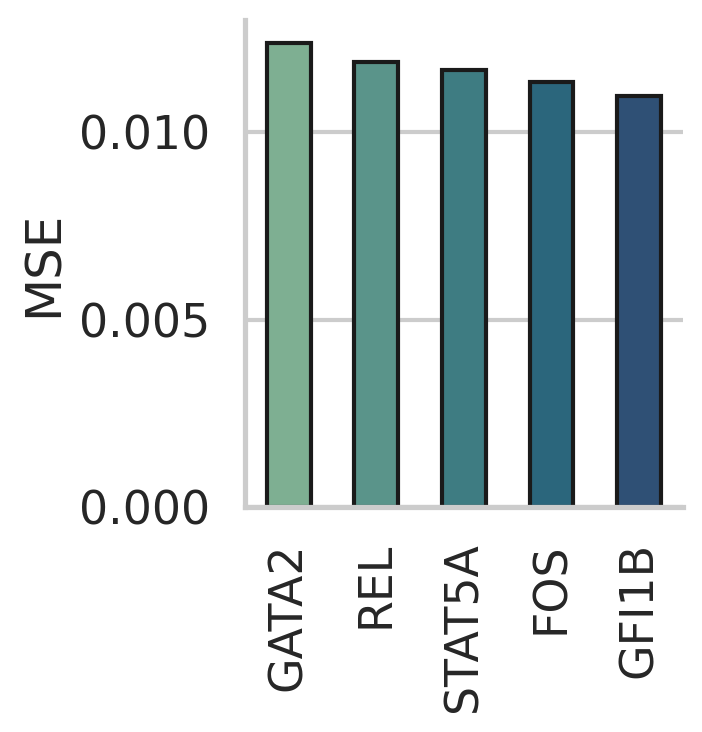

In [11]:
# get the single tf perturbations
tf_recipe = ['GATA2', 'GFI1B', 'FOS', 'STAT5A', 'REL']
query = [[x] for x in tf_recipe]
res = pd.DataFrame(gears_model.predict(query))
res.index = adata.var_names
print(f"{res.shape=}")
print(res.head().to_string())
print()

# Compute MSE per TF
mse_results = {}
for tf in tf_recipe:
    means = adata[adata.obs['condition'] == f'{tf}+ctrl'].to_df().mean()
    pred = res[tf]

    common_genes = res.index.intersection(means.index)
    mse = mean_squared_error(means[common_genes], pred[common_genes])
    mse_results[tf] = mse

# Convert to DataFrame for plotting
mse_df = pd.DataFrame.from_dict(mse_results, orient='index', columns=['MSE'])
mse_df = mse_df.sort_values('MSE', ascending=False)

# Plot
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4
sns.barplot(
    data=mse_df.reset_index(),
    x='index', 
    y='MSE', 
    palette='crest', 
    edgecolor='k',
    width=0.5,
)

plt.ylabel("MSE")
plt.xlabel("")
plt.gca().tick_params(axis='x', rotation=90)
sns.despine()
plt.tight_layout()
plt.show()

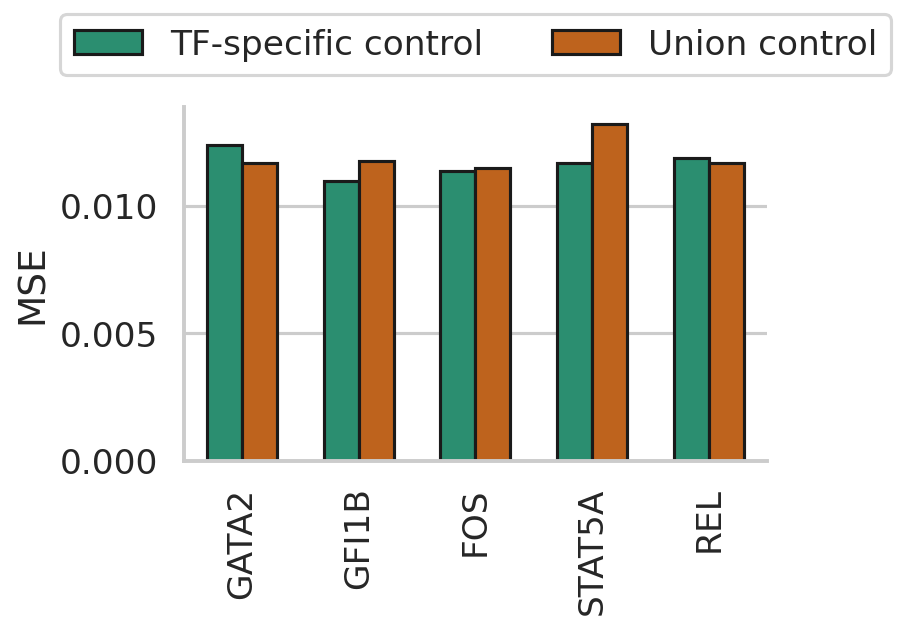

In [12]:
# TF list
tf_recipe = ['GATA2', 'GFI1B', 'FOS', 'STAT5A', 'REL']

# Get predictions
query = [[x] for x in tf_recipe]
res = pd.DataFrame(gears_model.predict(query))
res.index = adata.var_names

# Compute union-of-controls mean
all_ctrl = adata[adata.obs['condition'].isin([f'{tf}+ctrl' for tf in tf_recipe])]
union_means = all_ctrl.to_df().mean()

# Store both TF-specific and global MSEs
rows = []
for tf in tf_recipe:
    pred = res[tf]
    common_genes = res.index.intersection(union_means.index)
    
    # TF-specific control mean
    tf_means = adata[adata.obs['condition'] == f'{tf}+ctrl'].to_df().mean()
    tf_mse = mean_squared_error(tf_means[common_genes], pred[common_genes])
    rows.append({'TF': tf, 'MSE': tf_mse, 'Comparison': 'TF-specific control'})

    # Global union control mean
    global_mse = mean_squared_error(union_means[common_genes], pred[common_genes])
    rows.append({'TF': tf, 'MSE': global_mse, 'Comparison': 'Union control'})

# Convert to tidy DataFrame
mse_df = pd.DataFrame(rows)
mse_df.head()

# Plot
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 6, 5

sns.barplot(
    data=mse_df,
    x='TF',
    y='MSE',
    hue='Comparison',
    palette='Dark2',
    edgecolor='k',
    width=0.6,
)

plt.ylabel("MSE")
plt.xlabel("")
plt.xticks(rotation=90)
sns.move_legend(
    plt.gca(),
    title="",
    ncols=2,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.31),
)
sns.despine()
plt.tight_layout()
plt.show()

# GEARS-style output plot

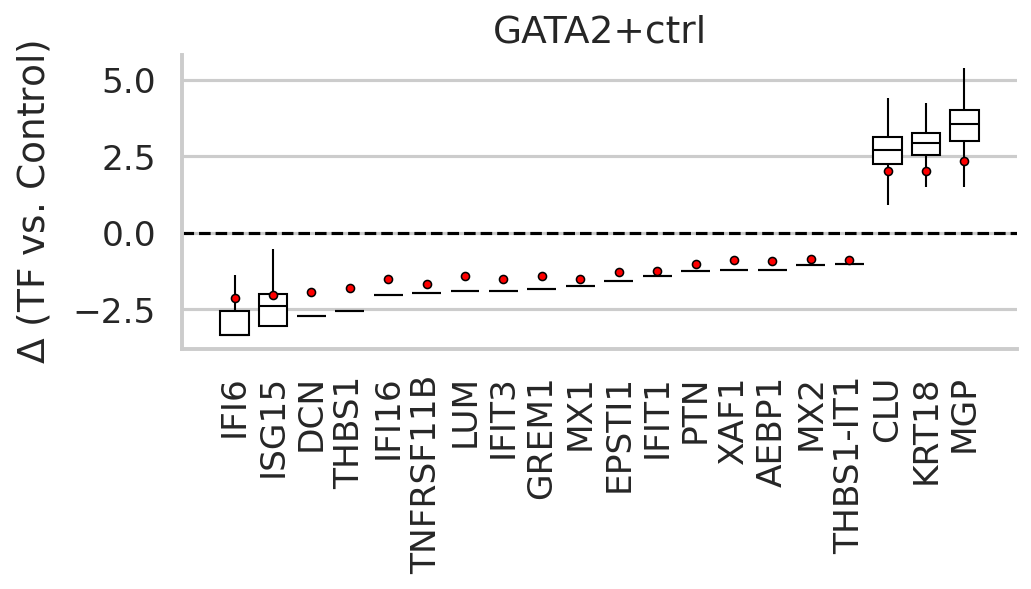

In [13]:
query = "GATA2+ctrl"

adata = gears_model.adata
gene2idx = gears_model.node_map
cond2name = dict(adata.obs[['condition', 'condition_name']].values)
gene_raw2id = dict(zip(adata.var.index.values, adata.var.gene_name.values))

# Get DE gene indices and names
de_idx = [gene2idx[gene_raw2id[i]] for i in adata.uns['top_non_dropout_de_20'][cond2name[query]]]
genes = [gene_raw2id[i] for i in adata.uns['top_non_dropout_de_20'][cond2name[query]]]

# True expression values and model prediction
truth = adata[adata.obs.condition == query].X.toarray()[:, de_idx]
query_ = [q for q in query.split('+') if q != 'ctrl']
pred = gears_model.predict([query_])['_'.join(query_)][de_idx]

# Compute control baseline
ctrl_means = adata[adata.obs['condition'] == 'ctrl'].to_df().mean()[de_idx].values

# Normalize to control
truth -= ctrl_means
pred -= ctrl_means

# Compute Δ expression relative to control
truth_delta = truth  # already subtracted ctrl_means
pred_delta = pred    # already subtracted ctrl_means

# Reshape true values to long format
truth_df = pd.DataFrame(truth_delta, columns=genes)
truth_long = truth_df.melt(var_name="Gene", value_name="Δ Expression")
truth_long["Source"] = "Observed"

# Create model prediction DataFrame
pred_df = pd.DataFrame({
    "Gene": genes,
    "Δ Expression": pred_delta,
    "Source": "Predicted"
})

# Combine
plot_df = pd.concat([truth_long, pred_df], ignore_index=True)
plot_df = plot_df.sort_values(by=['Source', 'Δ Expression'])

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = (7, 4)

# Boxplot for observed, scatter for predicted
sns.boxplot(
    data=plot_df[plot_df["Source"] == "Observed"],
    x="Gene", y="Δ Expression",
    showcaps=True,
    showfliers=False,
    width=0.75,
    boxprops={"facecolor": "white", "edgecolor": "black"},
    medianprops={"color": "black"},
    whiskerprops={"color": "black"},
    capprops={"lw" : 0,}
)

# Overlay predicted values
sns.scatterplot(
    data=plot_df[plot_df["Source"] == "Predicted"],
    x="Gene", y="Δ Expression",
    color="red",
    edgecolor="black",
    linewidth=0.75,
    s=15,
    zorder=10,
    label="Model Prediction",
    legend=False,
)

# Formatting
plt.axhline(0, linestyle="--", color="black", linewidth=1.5)
plt.ylabel(r"$\Delta$ (TF vs. Control)", labelpad=10)
plt.xlabel("")
plt.xticks(rotation=90)
sns.despine()
plt.tight_layout()
# plt.legend(frameon=False,)
plt.title(query)
plt.show()

# Correlation between predictions

ctrl_means.shape=(10000,)


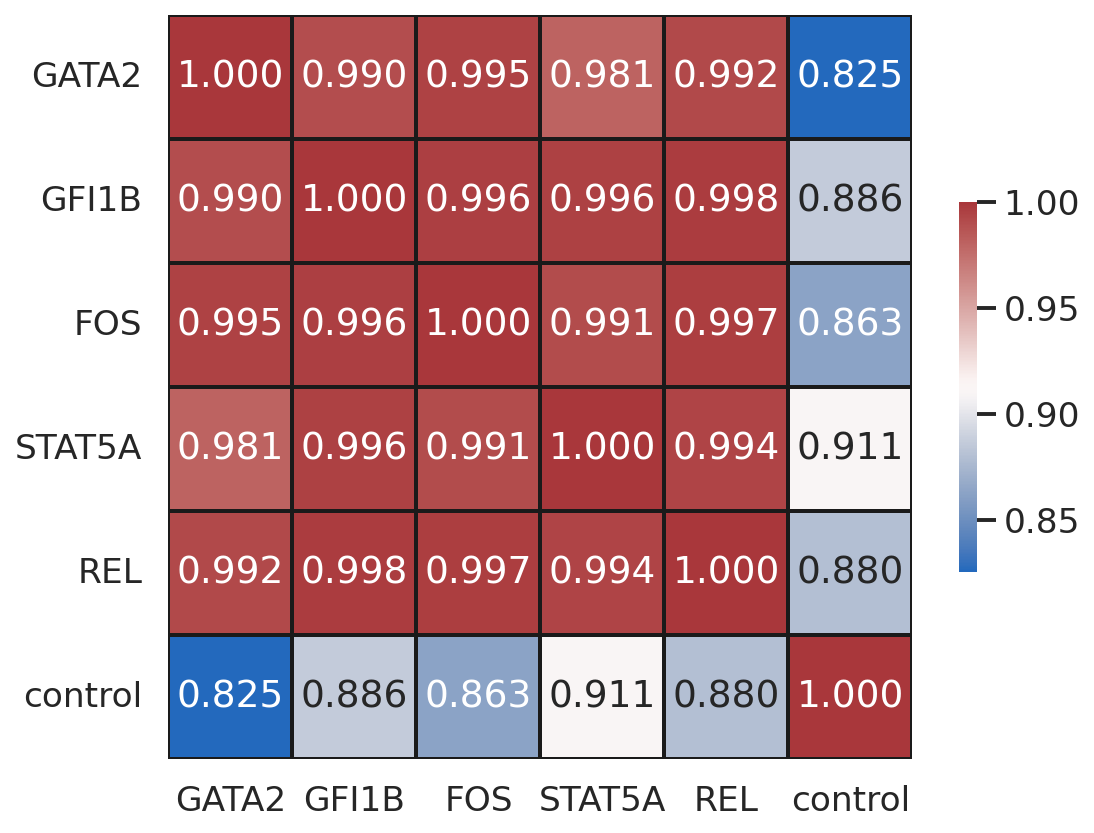

In [14]:
# get the control means
ctrl_means = adata[adata.obs['condition'] == 'ctrl'].to_df().mean()
print(f"{ctrl_means.shape=}")

# get the single tf perturbations
tf_recipe = ['GATA2', 'GFI1B', 'FOS', 'STAT5A', 'REL']
query = [[x] for x in tf_recipe]
res = pd.DataFrame(gears_model.predict(query))
res.index = adata.var_names

# add control means
res['control'] = ctrl_means

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 8, 8

sns.heatmap(
    res.corr(), 
    square=True, 
    annot=True,
    fmt=".3f",  # show 3 decimal places
    cmap='vlag',
    lw=1,
    linecolor='k',
    cbar_kws={'shrink': 0.4},
)


plt.gca().tick_params(axis='y', rotation=0)

# Predicted Expression 

In [15]:
# get the control means
ctrl_means = adata[adata.obs['condition'] == 'ctrl'].to_df().mean()
print(f"{ctrl_means.shape=}")

# get the single tf perturbations
tf_recipe = ['GATA2', 'GFI1B', 'FOS', 'STAT5A', 'REL']
query = [[x] for x in tf_recipe]
res = pd.DataFrame(gears_model.predict(query))
res.index = adata.var_names

#s shift to zero-min
res = res.sub(res.min())

# add control means
res['control'] = ctrl_means
print(f"{res.shape=}")

# add to fold change
fc_columns = []
for col in res.columns:
    new_column_name = f'log2FC_{col}'
    fc_columns.append(new_column_name)
    other_cols = [x for x in res.columns if not x == col]
    
    fold_change = np.log2(res[col] +1 / res[other_cols].mean(axis=1) + 1)
    res[new_column_name] = fold_change


print(res.head().to_string())

ctrl_means.shape=(10000,)
res.shape=(10000, 6)
           GATA2     GFI1B       FOS    STAT5A       REL   control  log2FC_GATA2  log2FC_GFI1B  log2FC_FOS  log2FC_STAT5A  log2FC_REL  log2FC_control
A2M     0.161946  0.096556  0.169170  0.102760  0.132552  0.090602      3.264989      1.393075    1.324474       1.207134    1.192079        1.135021
A4GALT  0.781624  0.603890  0.709800  0.515261  0.653692  0.051119      1.908803      1.537300    1.519291       1.347924    1.409514        0.971793
A4GNT   0.465573  0.339986  0.415539  0.276057  0.367739  0.007317      2.327730      1.533268    1.449907       1.283502    1.309761        1.022159
AAK1    1.140816  0.946566  1.042626  0.967207  1.039721  0.679165      1.682695      1.517167    1.546241       1.485929    1.514641        1.295926
AARD    0.177409  0.134914  0.178256  0.119940  0.183827  0.052858      3.111429      1.435131    1.333657       1.220757    1.228339        1.103605


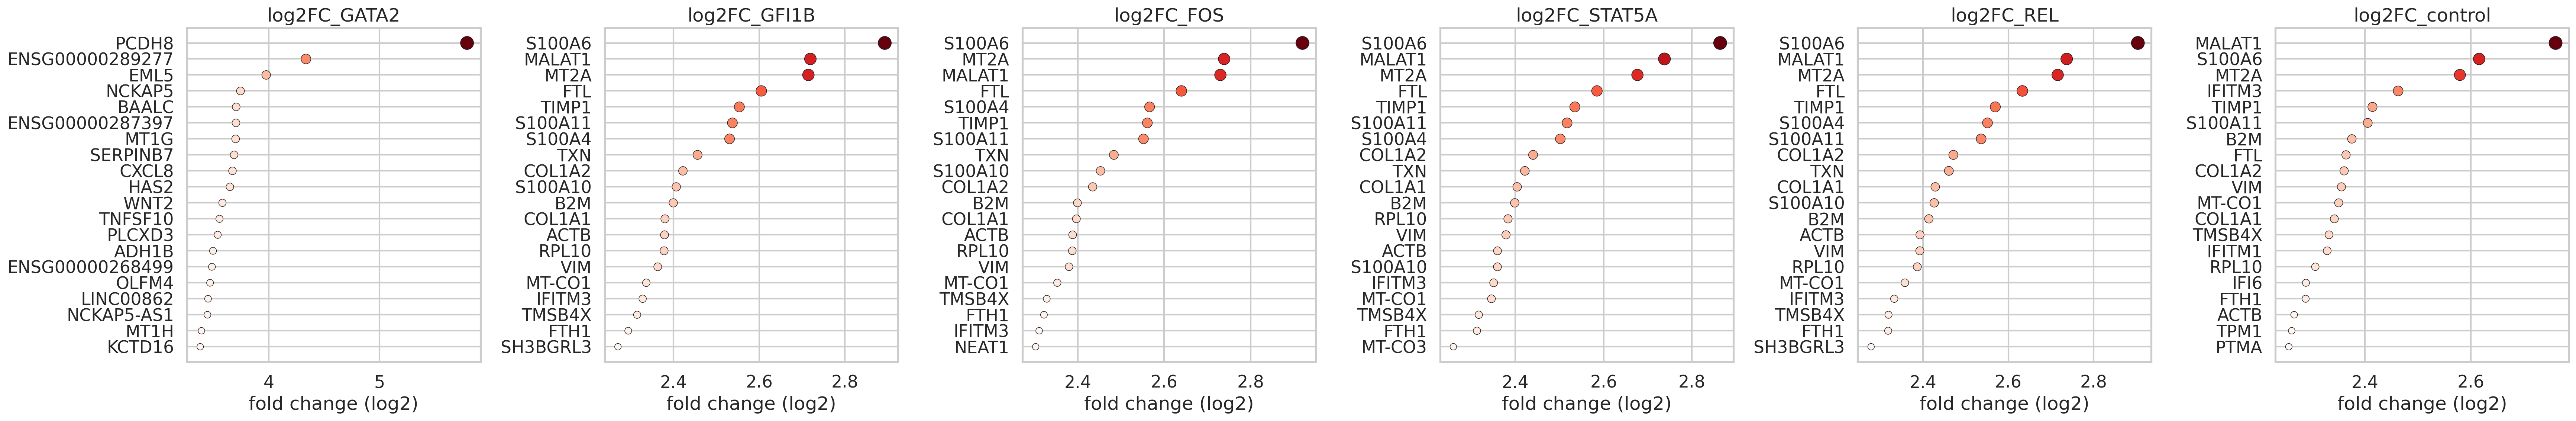

In [16]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 35, 6
fig, axes = plt.subplots(1, 6)

for i, column in enumerate(fc_columns):

    values = res[column].sort_values(ascending=False).reset_index()

    sns.scatterplot(
        data=values.head(20),
        x=column,
        y='index',
        hue=column,
        size=column,
        palette='Reds',
        ec='k',
        lw=0.5,
        ax=axes[i],
        zorder=5,
        legend=False,
    )
    axes[i].set_ylabel("")
    axes[i].set_xlabel("fold change (log2)")
    axes[i].set_title(column)
    axes[i].yaxis.grid(True, zorder=0)
    

plt.tight_layout()

In [17]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
# get the control means
ctrl_means = adata[adata.obs['condition'] == 'ctrl'].to_df().mean()
print(f"{ctrl_means.shape=}")

n_genes = 20

# get the single tf perturbations
tf_recipe = ['GATA2', 'GFI1B', 'FOS', 'STAT5A', 'REL']

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 20, 10
fig, axes = plt.subplots(1, 5)

for i, tf in enumerate(tf_recipe):
    res = pd.DataFrame(gears_model.predict([[tf]]))
    res.index = adata.var_names
    res = res.sub(res.min())
    res = res[~res.index.str.startswith('ENSG')]
    res['control'] = ctrl_means
    res['logfoldchange'] = np.log2(res[tf] / res['control'])
    res = res.sort_values(by='logfoldchange', ascending=False)
    res = res[np.isfinite(res['logfoldchange'])]

    res = pd.concat([res.head(n_genes), res.tail(n_genes)])
    res = res.reset_index(names='gene_name')
    
    sns.scatterplot(
        data=res,
        x="logfoldchange",
        y="gene_name",
        hue="logfoldchange",
        palette="vlag",
        size='logfoldchange',
        edgecolor="k",
        legend=False,
        linewidth=1,
        ax=axes[i],
    )
    axes[i].axvline(0, color='k', linestyle='--', lw=1)
    axes[i].set_title(tf)
    axes[i].set_xlabel("Fold Change (log2)")
    axes[i].set_ylabel("")
    axes[i].yaxis.grid(True)
    axes[i].xaxis.grid(False)
    axes[i].margins(x=0.1, y=0.05)

plt.tight_layout()

In [ ]:
# get the single tf perturbations
tf_recipe = ['GATA2', 'GFI1B', 'FOS', 'STAT5A', 'REL']
query = [[x] for x in tf_recipe]
res = pd.DataFrame(gears_model.predict(query))
res.index = adata.var_names
print(f"{res.shape=}")
print(res.head().to_string())

res

# Normalize each gene's delta across all conditions
res = res.sub(res.mean(axis=1), axis=0)

# Plot
ncols = len(res.columns)
plt.figure(figsize=(5 * ncols, 10), dpi=300)  # wider, shorter figure for horizontal layout

n = 20
for i, col in enumerate(res.columns):
    diff = res[col].sort_values()
    top_bottom = pd.concat([diff.head(n), diff.tail(n)])
    
    # Create tidy DataFrame
    df = pd.DataFrame({
        "Gene": top_bottom.index,
        "Δ Expression": top_bottom.values,
        "Condition": col
    })
    
    ax = plt.subplot(1, ncols, i + 1)
    sns.stripplot(
        data=df,
        x="Δ Expression",
        y="Gene",
        hue="Δ Expression",
        palette="vlag",
        size=8,
        edgecolor="k",
        linewidth=0.5,
        orient="h",
        dodge=False,
        alpha=0.85,
        ax=ax
    )
    plt.axvline(0, color='k', linestyle='--', lw=1)
    plt.title(col)
    plt.xlabel("Predicted Expression")
    plt.ylabel("")
    plt.legend([], [], frameon=False)
    ax.xaxis.grid(False)
    ax.yaxis.grid(True)

plt.tight_layout()
plt.show()

# TFs only

In [ ]:
fpath = "../../../resources/allTFs_hg38.txt"
tf_list = [x.strip() for x in open(fpath)]
tf_list[:10]

In [ ]:
# Plot
ncols = len(res.columns)
plt.figure(figsize=(4 * ncols, 10), dpi=300)  # wider, shorter figure for horizontal layout

res = res[res.index.isin(tf_list)]

n = 20
for i, col in enumerate(res.columns):
    diff = res[col].sort_values()
    top_bottom = pd.concat([diff.head(n), diff.tail(n)])
    
    # Create tidy DataFrame
    df = pd.DataFrame({
        "Gene": top_bottom.index,
        "Δ Expression": top_bottom.values,
        "Condition": col
    })
    
    ax = plt.subplot(1, ncols, i + 1)
    sns.stripplot(
        data=df,
        x="Δ Expression",
        y="Gene",
        hue="Δ Expression",
        palette="vlag",
        size=8,
        edgecolor="k",
        linewidth=0.5,
        orient="h",
        dodge=False,
        alpha=0.85,
        ax=ax
    )
    
    plt.axvline(0, color='k', linestyle='--', lw=1)
    plt.title(col)
    plt.xlabel("Predicted Expression")
    plt.ylabel("")
    plt.legend([], [], frameon=False)
    ax.xaxis.grid(False)
    ax.yaxis.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# get the control means
ctrl_means = adata[adata.obs['condition'] == 'ctrl'].to_df().mean()
print(f"{ctrl_means.shape=}")

# get the single tf perturbations
tf_recipe = ['GATA2', 'GFI1B', 'FOS', 'STAT5A', 'REL']
query = [[x] for x in tf_recipe]
res = pd.DataFrame(gears_model.predict(query))
res.index = adata.var_names

#s shift to zero-min
res = res.sub(res.min())

# add control means
res['control'] = ctrl_means
print(f"{res.shape=}")
print(res.head().to_string())

# column-wise min-max normalization
diff = res.subtract(res.min(axis=1), axis=0)

# Row-wise z-score normalization
diff = diff.sub(diff.mean(axis=1), axis=0)
diff = diff.div(diff.std(axis=1).replace(0, 1), axis=0)

# Plot top 10 per TF
ncols = diff.shape[1]
fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 10), sharey=False)

for ax, col in zip(axes, diff.columns):
    top10 = diff[col].nlargest(35)
    top10.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(col)
    ax.invert_yaxis()
    ax.set_xlabel("Δ vs control")

plt.tight_layout()
plt.show()

In [ ]:
break

# All TFs together

In [ ]:
tf_recipe = ['GATA2', 'GFI1B', 'FOS', 'STAT5A', 'REL']
res = pd.DataFrame(gears_model.predict([tf_recipe]))
res.index = adata.var_names
print(f"{res.shape=}")

# Compute union-of-controls mean
all_ctrl = adata[adata.obs['condition'].isin([f'{tf}+ctrl' for tf in tf_recipe])]
union_means = pd.DataFrame(all_ctrl.to_df().mean(), columns=['mean'])
print(f"{union_means.shape=}")

# Assume res has shape (genes, 1) and matches union_means in order
plot_df = pd.concat([res, union_means], axis=1)
plot_df.columns = ['pred', 'true']
plot_df['delta'] = plot_df['pred'] - plot_df['true']
plot_df = plot_df.sort_values('delta')

# Compute MSE
mse = mean_squared_error(plot_df['true'], plot_df['pred'])
print(f"MSE between prediction and union control means: {mse:.4f}")

# Top and bottom N differences
n = 15
top_bottom = pd.concat([plot_df.head(n), plot_df.tail(n)])
top_bottom = top_bottom.reset_index()

# Plot
plt.figure(figsize=(5, 6))
sns.barplot(
    data=top_bottom,
    x='delta',
    y='index',
    palette="vlag",
    edgecolor="k"
)
plt.axvline(0, color='k', linestyle='--', lw=1)
plt.xlabel("Δ Expression (Prediction − Mean)")
plt.ylabel("Gene")
sns.despine()
plt.tight_layout()
plt.show()

# Interactions

In [ ]:
break

In [ ]:
# tf_recipe = ['GATA2', 'GFI1B', 'FOS', 'STAT5A', 'REL']

# all_combinations = []
# for r in range(1, len(tf_recipe) + 1):
#     for idx in combinations(tf_recipe, r):
#         all_combinations += [list(idx)]

# res = pd.DataFrame(gears_model.predict(all_combinations))

# plt.rcParams['figure.dpi'] = 300
# plt.rcParams['figure.figsize'] = 25, 25

# sns.heatmap(
#     res.corr(), 
#     square=True, 
#     annot=True,
#     # vmin=0, 
#     # vmax=1,
#     cmap='vlag',
#     lw=1,
#     linecolor='k',
#     cbar_kws={'shrink' : 0.4},
# )

# plt.gca().tick_params(axis='y', rotation=0)

In [ ]:
res.shape

In [ ]:
break

In [ ]:
break